<a href="https://colab.research.google.com/github/fcoliveira-utfpr/climate_parana/blob/main/03_climate_dominance_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Start – Libraries
---

In [ ]:
# =========================================================
# REQUIRED LIBRARIES
# =========================================================
!pip install geobr geopandas rasterio elevation cartopy matplotlib-scalebar --quiet
# =========================================================
# IMPORT LIBRARIES
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import geobr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from geobr import read_municipality
from matplotlib_scalebar.scalebar import ScaleBar
import warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 84.7 MB/s eta 0:00:00


#Climate dominance classification
---

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


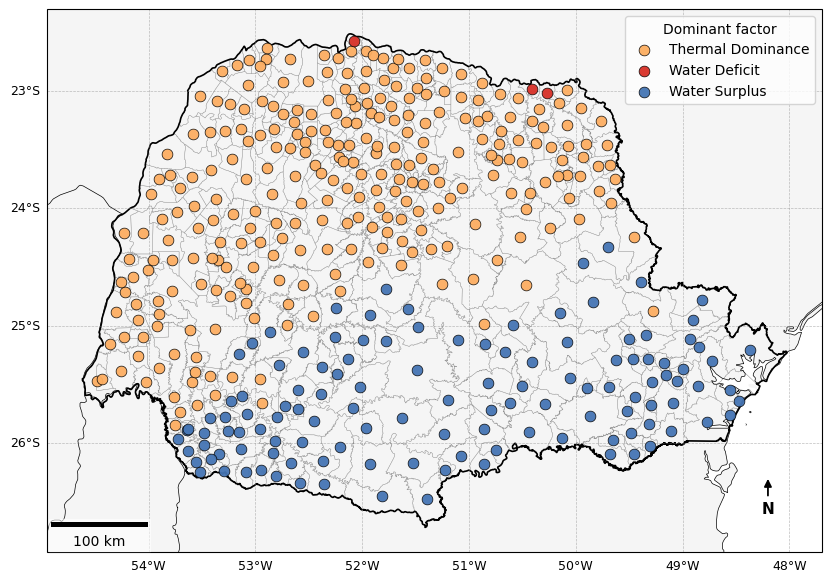

In [ ]:

# =========================================================
# LOAD DATA
# =========================================================
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/climate_parana/refs/heads/main/dados_concatenados_zc.csv"
df = pd.read_csv(url, sep=",")

df['variavel'] = df['variavel'].str.lower()

df_clima = (
    df.pivot_table(
        index=['estado', 'municipio', 'lat', 'lon', 'ZC'],
        columns='variavel',
        values='valor',
        aggfunc='mean'
    )
    .reset_index()
)

df_dom = df_clima.copy()

# ---------------------------------------------------------
# SUPPRESS WARNINGS
# ---------------------------------------------------------
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


# =========================================================
# NORMALIZATION (0–1)
# =========================================================
for v in ['def', 'ro', 'pet', 'tmmx']:
    df_dom[v + '_n'] = (
        df_dom[v] - df_dom[v].min()
    ) / (df_dom[v].max() - df_dom[v].min())

df_dom['hid_def'] = df_dom['def_n']
df_dom['hid_exc'] = df_dom['ro_n']
df_dom['termico'] = 0.5 * df_dom['pet_n'] + 0.5 * df_dom['tmmx_n']

df_dom['dom_clima'] = df_dom[['hid_def', 'hid_exc', 'termico']].idxmax(axis=1)

dom_clima_mapping = {
    'hid_def': 'Water Deficit',
    'hid_exc': 'Water Surplus',
    'termico': 'Thermal Dominance'
}

df_dom['dom_clima'] = df_dom['dom_clima'].replace(dom_clima_mapping)

# =========================================================
# LOAD STATE AND MUNICIPAL BOUNDARIES
# =========================================================
pr = geobr.read_state(code_state='PR', year=2020).to_crs(epsg=4326)
mun_pr = read_municipality(code_muni="PR", year=2020).to_crs(epsg=4326)

# =========================================================
# CREATE MAP
# =========================================================
fig = plt.figure(figsize=(10, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

# Extent with small margin
minx, miny, maxx, maxy = pr.total_bounds
dx = (maxx - minx) * 0.05
dy = (maxy - miny) * 0.05

ax.set_extent(
    [minx - dx, maxx + dx, miny - dy, maxy + dy],
    crs=ccrs.PlateCarree()
)

# Background
ax.add_feature(cfeature.LAND, facecolor='#F5F5F5')
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# =========================================================
# MUNICIPAL LIMITS (thin)
# =========================================================
mun_pr.boundary.plot(
    ax=ax,
    edgecolor='gray',
    linewidth=0.3,
    alpha=0.6,
    transform=ccrs.PlateCarree(),
    zorder=1
)

# =========================================================
# STATE BOUNDARY (highlighted)
# =========================================================
pr.boundary.plot(
    ax=ax,
    edgecolor='black',
    linewidth=1.2,
    transform=ccrs.PlateCarree(),
    zorder=2
)

# =========================================================
# COLOR SCHEME
# =========================================================
colors = {
    'Water Deficit': '#d73027',
    'Water Surplus': '#4575b4',
    'Thermal Dominance': '#fdae61'
}

# =========================================================
# PLOT POINTS
# =========================================================
for c, g in df_dom.groupby('dom_clima'):
    ax.scatter(
        g['lon'],
        g['lat'],
        s=60,
        color=colors[c],
        edgecolor='black',
        linewidth=0.5,
        alpha=0.95,
        label=c,
        transform=ccrs.PlateCarree(),
        zorder=5
    )

# =========================================================
# GRIDLINES
# =========================================================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}

# =========================================================
# NORTH ARROW
# =========================================================
ax.annotate(
    'N',
    xy=(0.93, 0.14),
    xytext=(0.93, 0.08),
    xycoords='axes fraction',
    textcoords='axes fraction',
    ha='center',
    va='center',
    fontsize=11,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='-|>',
        linewidth=1.3,
        color='black'
    )
)


# =========================================================
# SCALE BAR
# =========================================================
scalebar = ScaleBar(
    dx=111000,
    units='m',
    fixed_value=100000,
    scale_formatter=lambda value, unit: f"{int(value/1000)} km",
    location='lower left',
    box_alpha=0.5
)

ax.add_artist(scalebar)

# =========================================================
# LEGEND
# =========================================================
ax.legend(
    title='Dominant factor',
    loc='upper right',
    frameon=True
)


# ---------------------------------------------------------
# EXPORT
# ---------------------------------------------------------
plt.savefig("Figure5.png", dpi=600, bbox_inches='tight')
plt.show()


#General statistics
---

In [ ]:
df_stats_geral = (
    df_dom[['def','ro','pet','tmmx']]
    .describe()
    .T
)

df_stats_geral


,count,mean,std,min,25%,50%,75%,max
variavel,,,,,,,,
def,400.0,139.015056,81.245109,20.466911,70.263379,130.051252,190.060746,365.104803
ro,400.0,515.267743,203.163948,204.898911,336.992722,491.008405,675.415724,1163.776410
pet,400.0,1161.065542,96.788913,929.785119,1116.514017,1169.627390,1232.716390,1336.130219
tmmx,400.0,25.995250,1.727999,21.739851,24.980161,26.192023,27.284616,29.131769


In [ ]:
df_stats_zc = (
    df_dom
    .groupby('ZC')[['def','ro','pet','tmmx']]
    .agg(['mean','std','min','max'])
)

df_stats_zc
df_stats_zc.columns = ['_'.join(col).strip() for col in df_stats_zc.columns.values]
df_stats_zc.reset_index( )


,ZC,def_mean,def_std,def_min,def_max,ro_mean,ro_std,ro_min,ro_max,pet_mean,pet_std,pet_min,pet_max,tmmx_mean,tmmx_std,tmmx_min,tmmx_max
0,5901,32.307809,5.587111,26.371394,39.637645,803.085829,24.348398,770.379859,828.715640,1027.572833,28.765803,994.232067,1060.266737,22.414912,0.471409,21.949541,22.898825
1,6601,139.288702,NaN,139.288702,139.288702,334.058025,NaN,334.058025,334.058025,1122.242573,NaN,1122.242573,1122.242573,25.940854,NaN,25.940854,25.940854
2,6701,76.640853,31.204035,39.676640,130.551731,481.214203,67.709384,359.477913,587.439798,1029.586004,74.223380,936.039670,1138.108824,24.118362,1.180774,22.505647,25.591490
3,6801,65.301483,21.246359,27.543155,114.489381,688.645396,93.310647,476.331028,848.290358,1087.933679,84.436677,929.785119,1199.178625,24.380985,1.159792,21.739851,26.189029
4,6901,52.141434,17.113930,25.941793,77.105363,872.583468,76.391832,721.883707,1015.452249,1107.771204,76.941063,984.188122,1194.787438,24.108070,0.950446,22.677536,25.376489
5,7501,308.842164,25.788860,254.537307,365.104803,236.146553,19.114700,204.898911,278.767484,1300.264259,23.579486,1252.036223,1336.130219,28.681586,0.269955,28.057976,29.131769
6,7601,229.418138,42.899048,153.111364,324.600713,302.260516,31.399227,241.170396,382.464140,1224.091089,54.249502,1104.984348,1327.342767,27.559608,0.762362,25.773120,28.843600
7,7701,159.633022,29.003340,96.882292,237.518535,414.310280,56.806299,314.348624,514.353773,1186.662218,57.090190,1077.894336,1305.906440,26.626299,0.738926,25.012749,28.208377
8,7801,117.255449,18.527245,86.391904,152.859914,581.317280,78.760244,460.607100,748.052548,1212.486376,45.259859,1133.296456,1295.565724,26.527637,0.630700,25.118037,27.677098
9,7901,24.031643,3.873904,20.466911,30.535814,1090.274242,77.305140,975.347574,1163.776410,1000.477791,20.956861,975.924227,1031.952195,24.777153,0.492306,23.996178,25.443091


In [ ]:
df_stats_dom = (
    df_dom
    .groupby('dom_clima')[['def','ro','pet','tmmx']]
    .describe()
)

df_stats_dom.columns = ['_'.join(col).strip() for col in df_stats_dom.columns.values]
df_stats_dom.reset_index(inplace=True)
df_stats_dom

,dom_clima,def_count,def_mean,def_std,def_min,def_25%,def_50%,def_75%,def_max,ro_count,...,pet_75%,pet_max,tmmx_count,tmmx_mean,tmmx_std,tmmx_min,tmmx_25%,tmmx_50%,tmmx_75%,tmmx_max
0,Thermal Dominance,274.0,175.044902,67.367645,62.584152,125.736046,156.946937,220.705332,343.147465,274.0,...,1259.856827,1336.130219,274.0,26.863101,1.087672,24.201903,26.028005,26.738126,27.683330,28.993197
1,Water Deficit,3.0,330.653658,30.781401,305.856190,313.428086,320.999982,343.052392,365.104803,3.0,...,1287.017948,1318.038709,3.0,28.605281,0.473717,28.213525,28.342036,28.470547,28.801158,29.131769
2,Water Surplus,123.0,54.079337,18.022702,20.466911,39.525159,53.937041,68.249948,88.000623,123.0,...,1145.442657,1195.747144,123.0,23.998329,1.111415,21.739851,23.163662,23.927011,24.963778,25.919790


In [ ]:
df_freq_dom = (
    df_dom['dom_clima']
    .value_counts()
    .to_frame(name='n_municipios')
)

df_freq_dom['percent_%'] = (
    df_freq_dom['n_municipios'] /
    df_freq_dom['n_municipios'].sum() * 100
)

df_freq_dom


,n_municipios,percent_%
dom_clima,,
Thermal Dominance,274,68.50
Water Surplus,123,30.75
Water Deficit,3,0.75


In [ ]:
df_norm = df_dom[
    ['municipio','ZC','def_n','ro_n','pet_n','tmmx_n','termico']
].copy()
df_norm

variavel,municipio,ZC,def_n,ro_n,pet_n,tmmx_n,termico
0,ABATIA,7601,0.552032,0.111232,0.681377,0.722614,0.701995
1,ADRIANOPOLIS,6801,0.097432,0.354215,0.207085,0.482128,0.344606
2,AGUDOS DO SUL,6801,0.036868,0.483171,0.007409,0.027107,0.017258
3,ALMIRANTE TAMANDARE,6801,0.043119,0.633970,0.102143,0.116732,0.109438
4,ALTAMIRA DO PARANA,6801,0.229562,0.420298,0.577891,0.569429,0.573660
...,...,...,...,...,...,...,...
395,VERE,6801,0.144586,0.621919,0.585963,0.524676,0.555320
396,VIRMOND,6801,0.127560,0.525493,0.453286,0.355663,0.404474
397,VITORINO,6901,0.107657,0.682469,0.548497,0.398352,0.473425
398,WENCESLAU BRAZ,7601,0.439655,0.092270,0.487903,0.571921,0.529912


In [ ]:
map_dom_num = {
    'Water Deficit': 1,
    'Water Surplus': 2,
    'Thermal Dominance': 3
}

df_dom['dom_num'] = df_dom['dom_clima'].map(map_dom_num)
df_dom

variavel,estado,municipio,lat,lon,ZC,def,pet,pr,ro,tmmn,tmmx,def_n,ro_n,pet_n,tmmx_n,hid_def,hid_exc,termico,dom_clima,dom_num
0,Parana,ABATIA,-23.311363,-50.306176,7601,210.718086,1206.659398,1307.379253,311.556630,15.127665,27.081352,0.552032,0.111232,0.681377,0.722614,0.552032,0.111232,0.701995,Thermal Dominance,3
1,Parana,ADRIANOPOLIS,-24.781986,-48.819381,6801,54.045608,1013.932958,1505.512165,544.547239,15.256973,25.303699,0.097432,0.354215,0.207085,0.482128,0.097432,0.354215,0.344606,Water Surplus,2
2,Parana,AGUDOS DO SUL,-26.025501,-49.309155,6801,33.173108,932.795928,1568.640344,668.200648,12.061930,21.940224,0.036868,0.483171,0.007409,0.027107,0.036868,0.483171,0.017258,Water Surplus,2
3,Parana,ALMIRANTE TAMANDARE,-25.284879,-49.322794,6801,35.327444,971.290520,1749.590688,812.798507,12.630313,22.602725,0.043119,0.633970,0.102143,0.116732,0.043119,0.633970,0.109438,Water Surplus,2
4,Parana,ALTAMIRA DO PARANA,-24.812720,-52.691907,6801,99.582733,1164.608342,1673.702794,607.913095,14.157846,25.949021,0.229562,0.420298,0.577891,0.569429,0.229562,0.420298,0.573660,Thermal Dominance,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,Parana,VERE,-25.877241,-52.961226,6801,70.296891,1167.888375,1899.380348,801.242683,12.239027,25.618214,0.144586,0.621919,0.585963,0.524676,0.144586,0.621919,0.555320,Water Surplus,2
396,Parana,VIRMOND,-25.408510,-52.236439,6801,64.428900,1113.975685,1758.946594,708.782585,12.586449,24.368879,0.127560,0.525493,0.453286,0.355663,0.127560,0.525493,0.404474,Water Surplus,2
397,Parana,VITORINO,-26.277366,-52.804057,6901,57.569478,1152.664105,1954.722526,859.303535,11.191796,24.684439,0.107657,0.682469,0.548497,0.398352,0.107657,0.682469,0.473425,Water Surplus,2
398,Parana,WENCESLAU BRAZ,-23.853953,-49.783944,7601,171.988728,1128.042085,1250.465954,293.374888,14.551194,25.967448,0.439655,0.092270,0.487903,0.571921,0.439655,0.092270,0.529912,Thermal Dominance,3


In [ ]:
df_dom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   estado     400 non-null    object 
 1   municipio  400 non-null    object 
 2   lat        400 non-null    float64
 3   lon        400 non-null    float64
 4   ZC         400 non-null    int64  
 5   def        400 non-null    float64
 6   pet        400 non-null    float64
 7   pr         400 non-null    float64
 8   ro         400 non-null    float64
 9   tmmn       400 non-null    float64
 10  tmmx       400 non-null    float64
 11  def_n      400 non-null    float64
 12  ro_n       400 non-null    float64
 13  pet_n      400 non-null    float64
 14  tmmx_n     400 non-null    float64
 15  hid_def    400 non-null    float64
 16  hid_exc    400 non-null    float64
 17  termico    400 non-null    float64
 18  dom_clima  400 non-null    object 
 19  dom_num    400 non-null    int64  
dtypes: float64

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


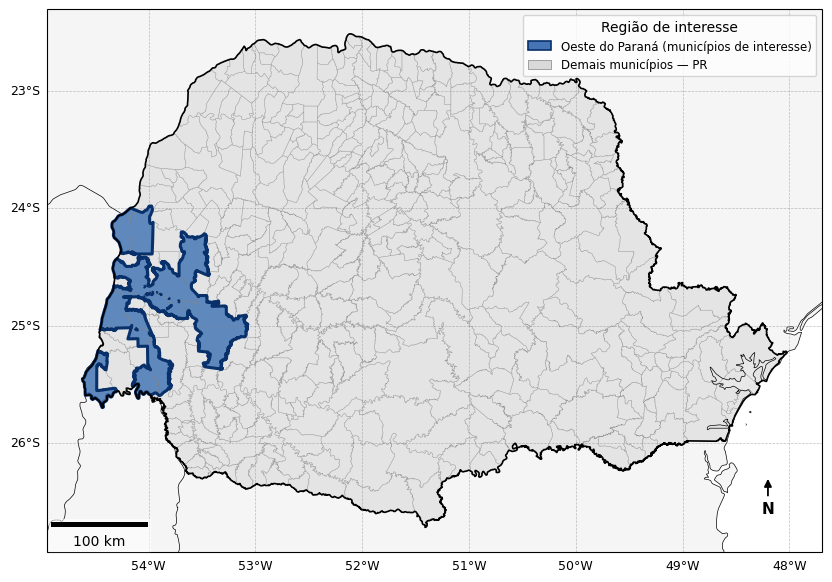

In [ ]:
# =========================================================
# REQUIRED LIBRARIES
# =========================================================
!pip install geobr geopandas rasterio elevation cartopy matplotlib-scalebar --quiet

# =========================================================
# IMPORT LIBRARIES
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import geobr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from geobr import read_municipality
from matplotlib_scalebar.scalebar import ScaleBar
import unicodedata
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


# =========================================================
# MUNICÍPIOS A DESTACAR (Oeste do Paraná)
# =========================================================
municipios_destaque = [
    "Santa Helena",
    "Marechal Candido Rondon",
    "Toledo",
    "Cascavel",
    "Foz do Iguacu",
    "Guaira",
    "Assis Chateaubriand",
    "Diamante D'Oeste",
    "Matelândia",
    "Entre Rios do Oeste",
    "Ramilândia",
    "Terra Roxa",
    "Serranópolis do Iguaçu",
    "Ouro Verde do Oeste"
]

def normalize_str(s):
    """Remove acentos e converte para minúsculas para comparação."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', str(s))
        if unicodedata.category(c) != 'Mn'
    ).lower().strip()

municipios_destaque_norm = [normalize_str(m) for m in municipios_destaque]


# =========================================================
# LOAD STATE AND MUNICIPAL BOUNDARIES
# =========================================================
pr     = geobr.read_state(code_state='PR', year=2020).to_crs(epsg=4326)
mun_pr = read_municipality(code_muni="PR", year=2020).to_crs(epsg=4326)

# Normaliza nomes
mun_pr['nome_norm'] = mun_pr['name_muni'].apply(normalize_str)

# Separa os grupos
mun_destaque = mun_pr[mun_pr['nome_norm'].isin(municipios_destaque_norm)].copy()
mun_restante = mun_pr[~mun_pr['nome_norm'].isin(municipios_destaque_norm)].copy()

# Contorno unificado da região de interesse
contorno_oeste = mun_destaque.dissolve()


# =========================================================
# CREATE MAP  (mesmo estilo do original)
# =========================================================
fig = plt.figure(figsize=(10, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

# Extent com pequena margem
minx, miny, maxx, maxy = pr.total_bounds
dx = (maxx - minx) * 0.05
dy = (maxy - miny) * 0.05

ax.set_extent(
    [minx - dx, maxx + dx, miny - dy, maxy + dy],
    crs=ccrs.PlateCarree()
)

# Background
ax.add_feature(cfeature.LAND,      facecolor='#F5F5F5')
ax.add_feature(cfeature.BORDERS,   linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)


# =========================================================
# MUNICÍPIOS RESTANTES (cinza neutro, linhas finas)
# =========================================================
mun_restante.plot(
    ax=ax,
    facecolor='#D9D9D9',
    edgecolor='gray',
    linewidth=0.3,
    alpha=0.6,
    transform=ccrs.PlateCarree(),
    zorder=1
)

# =========================================================
# MUNICÍPIOS DO OESTE — coloridos
# =========================================================
mun_destaque.plot(
    ax=ax,
    facecolor='#4575b4',       # azul — ajuste a cor conforme desejado
    edgecolor='gray',
    linewidth=0.3,
    alpha=0.85,
    transform=ccrs.PlateCarree(),
    zorder=2
)

# =========================================================
# CONTORNO EXTERNO DO OESTE DO PARANÁ (linha grossa)
# =========================================================
contorno_oeste.boundary.plot(
    ax=ax,
    edgecolor='#08306b',       # azul escuro
    linewidth=2.2,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# =========================================================
# BORDA ESTADUAL (mesmo do original)
# =========================================================
pr.boundary.plot(
    ax=ax,
    edgecolor='black',
    linewidth=1.2,
    transform=ccrs.PlateCarree(),
    zorder=4
)


# =========================================================
# GRIDLINES  (mesmo do original)
# =========================================================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.5,
    linestyle='--'
)
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}


# =========================================================
# NORTH ARROW  (mesmo do original)
# =========================================================
ax.annotate(
    'N',
    xy=(0.93, 0.14),
    xytext=(0.93, 0.08),
    xycoords='axes fraction',
    textcoords='axes fraction',
    ha='center',
    va='center',
    fontsize=11,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='-|>',
        linewidth=1.3,
        color='black'
    )
)


# =========================================================
# SCALE BAR  (mesmo do original)
# =========================================================
scalebar = ScaleBar(
    dx=111000,
    units='m',
    fixed_value=100000,
    scale_formatter=lambda value, unit: f"{int(value/1000)} km",
    location='lower left',
    box_alpha=0.5
)
ax.add_artist(scalebar)


# =========================================================
# LEGENDA
# =========================================================
patch_oeste   = mpatches.Patch(facecolor='#4575b4', edgecolor='#08306b',
                                linewidth=1.2, label='Oeste do Paraná (municípios de interesse)')
patch_restante = mpatches.Patch(facecolor='#D9D9D9', edgecolor='gray',
                                 linewidth=0.5, label='Demais municípios — PR')

ax.legend(
    handles=[patch_oeste, patch_restante],
    title='Região de interesse',
    loc='upper right',
    frameon=True,
    fontsize=8.5
)


# =========================================================
# EXPORT  (mesmo do original)
# =========================================================
plt.savefig("Figure5.png", dpi=600, bbox_inches='tight')
plt.show()